In [2]:
import sys
sys.path.append('../scripts')  # Adjust path as needed
from module import (
    count_usage_cases,
    create_degree_lists,
    count_cluster_wise,
    pre_vec,
    nordept,
    deptwisecount,
    normalized_dept_cluster,
    create_vector,
    create_vector2,
    clear_vec,
    culster_wise_val,
    create_con_table,
    chi_square_test,
    residuals_cal,
    create_group,
    normality_test,
    agostino_pearson_test,
    kruskal_wallis_test
)
from plots import ( grouped_bar_graph_horizontal_color, stacked_bar_graph, grouped_bar_graph_horizontal_color_white, boxplot,
    kde_plot,
    heatmap_plot
)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.patches as mpatches  # For patterns

In [4]:
file_path = '/Users/jesanahammed/Desktop/dataset/survey25.csv'
df = pd.read_csv(file_path, encoding='latin1')
#df.columns = df.columns.str.replace(r'[^\x00-\x7F]+', '', regex=True)  # Remove non-ASCII characters
#df.columns = df.columns.str.strip()  # Strip any leading/trailing spaces

In [5]:
# Keep only rows where 'Response Status' is 'Completed'
df = df[df['Response Status'] == 'Completed']

# Optional: reset index
df.reset_index(drop=True, inplace=True)

In [6]:
print(len(df['Response ID']))

1345


In [7]:
#df.columns.tolist()

In [8]:
p_doom_var = "If you would like, please share your own estimate for p(doom) by entering a number between 0 and 100; do not include the percent sign (%). (Optional)0 means that there is no chance whatsoever of AI causing catastrophic outcomes, and 100 means that AI will definitely have catastrophic outcomes for humanity."

In [22]:
p_doom = df[p_doom_var]

In [23]:
p_doom

0        60
1        10
2        95
3        30
4        75
       ... 
1340    NaN
1341    NaN
1342    NaN
1343     65
1344    NaN
Name: If you would like, please share your own estimate for p(doom) by entering a number between 0 and 100; do not include the percent sign (%). (Optional)0 means that there is no chance whatsoever of AI causing catastrophic outcomes, and 100 means that AI will definitely have catastrophic outcomes for humanity., Length: 1345, dtype: object

In [12]:
role = df["Are you a current member of the Mines community?"]

In [39]:
role.value_counts()

Are you a current member of the Mines community?
1.0    1061
2.0     284
Name: count, dtype: int64

In [52]:
# Select only the p_doom_var values for each group
student = df.loc[role == 1, p_doom_var]
faculty = df.loc[role == 2, p_doom_var]


In [53]:
len(student)

1061

In [54]:
len(faculty)

284

In [55]:
student.isna().sum()

254

In [56]:
faculty.isna().sum()

87

In [57]:
len(student)

1061

In [62]:
student.dtype

dtype('O')

In [63]:
pd.api.types.is_numeric_dtype(student)


False

In [64]:
student_numeric = pd.to_numeric(student, errors='coerce')


In [65]:
student_numeric.dtype

dtype('float64')

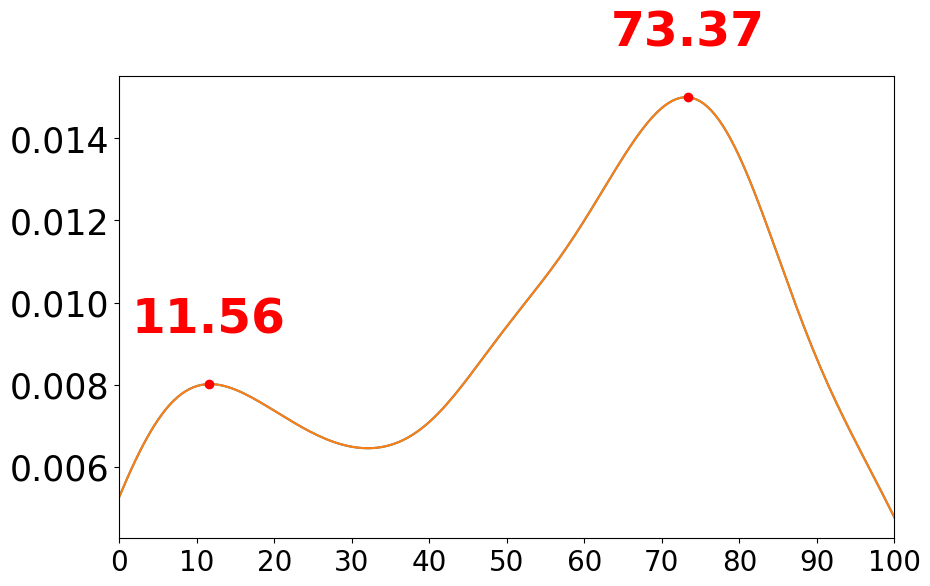

Peak values are at: [11.55778894 73.36683417]


In [68]:
kde_plot(student_numeric, 0, 100, 0.001, 11, 'Student P(doom) 2025.png', "Estimation", "Density") # peak font size 25

In [69]:
student_clean = student_numeric.dropna()


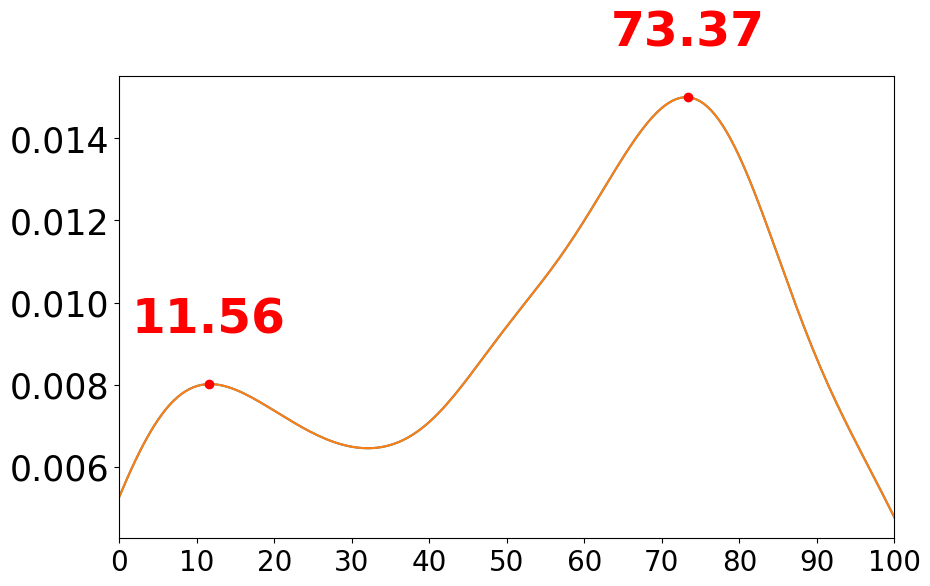

Peak values are at: [11.55778894 73.36683417]


In [70]:
kde_plot(student_clean, 0, 100, 0.001, 11, 'Student P(doom) 2025.png', "Estimation", "Density") # peak font size 25

In [71]:
faculty_numeric = pd.to_numeric(faculty, errors='coerce')


284


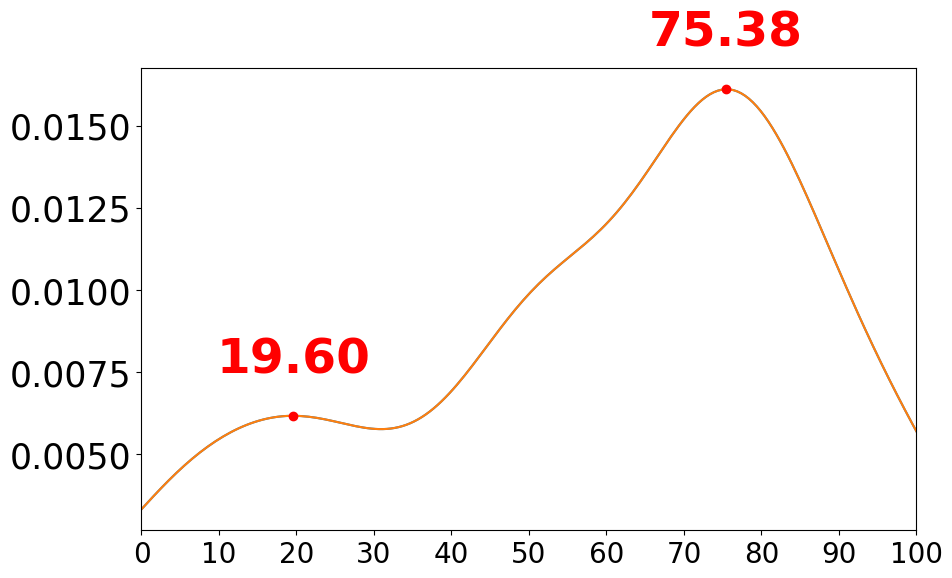

Peak values are at: [19.59798995 75.37688442]


In [74]:
print(len(faculty_numeric))
kde_plot(faculty_numeric, 0, 100, 0.001, 11, 'Faculty P(doom) 2025.png', "Estimation", "Density") # peak font size 25

In [9]:
freq_llm_chatbot = df["How frequently have you used the following GenAI-based tools so far this semester for your classes, research, and/or any other professional efforts?"]

In [10]:
freq_llm_chatbot.value_counts()

How frequently have you used the following GenAI-based tools so far this semester for your classes, research, and/or any other professional efforts?
3    496
2    297
4    287
6    115
1    106
5     44
Name: count, dtype: int64

In [14]:
student_freq = df.loc[role == 1, "How frequently have you used the following GenAI-based tools so far this semester for your classes, research, and/or any other professional efforts?"]


In [19]:
(student_freq.value_counts() / student_freq.value_counts().sum()) * 100

How frequently have you used the following GenAI-based tools so far this semester for your classes, research, and/or any other professional efforts?
3    39.019793
4    22.243167
2    19.604147
1     8.105561
6     7.540057
5     3.487276
Name: count, dtype: float64

In [20]:
faculty_freq = df.loc[role == 2, "How frequently have you used the following GenAI-based tools so far this semester for your classes, research, and/or any other professional efforts?"]


In [21]:
(faculty_freq.value_counts() / faculty_freq.value_counts().sum()) * 100

How frequently have you used the following GenAI-based tools so far this semester for your classes, research, and/or any other professional efforts?
2    31.338028
3    28.873239
4    17.957746
6    12.323944
1     7.042254
5     2.464789
Name: count, dtype: float64

In [31]:
student_23 = {
    "Never": 30.8,
    "Irregular": 30.8,
    "Regular": 22.5,
    "Super User": 9.3,
    "Having Fun": 6.7
}

In [32]:
student_24 = {
    "Never": 17.9,
    "Irregular": 30.5,
    "Regular": 32.3,
    "Super User": 12.8,
    "Having Fun": 6.6
}

In [33]:
student_25 = {
    "Never": 7.5,
    "Irregular": 19.6,
    "Regular": 39.0,
    "Super User": 22.2,
    "Having Fun": 3.5
}

In [34]:
faculty_23 = {
    "Never": 29.5,
    "Irregular": 35.8,
    "Regular": 18.9,
    "Super User": 9.5,
    "Having Fun": 6.3
}

In [35]:
faculty_25 = {
    "Never": 12.32,
    "Irregular": 31.3,
    "Regular": 28.9,
    "Super User": 18,
    "Having Fun": 2.5
}

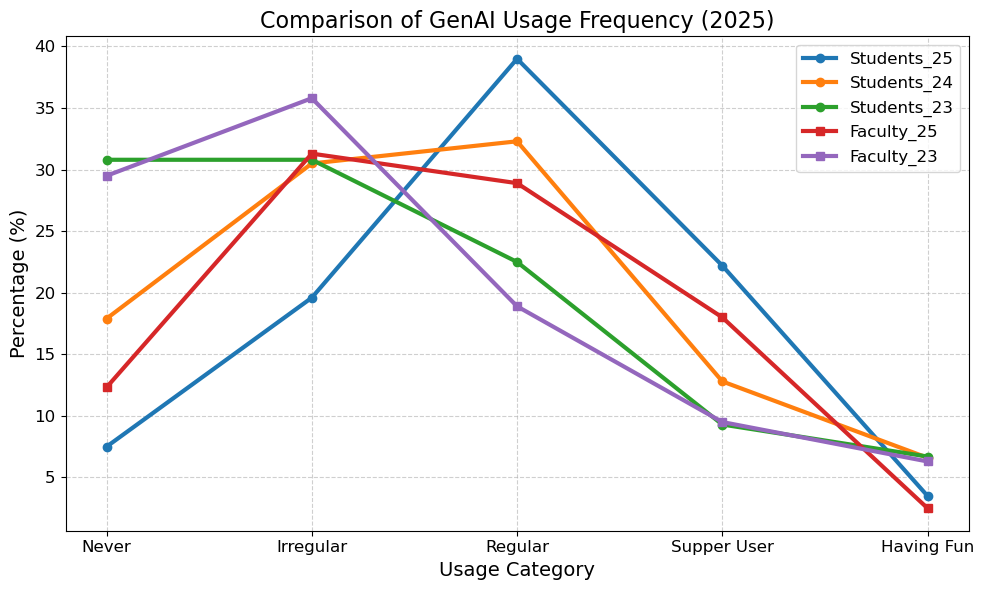

In [28]:
# Ensure same order of categories
categories = list(student_25.keys())

# Extract values
student_values_25 = [student_25[c] for c in categories]
faculty_values_25 = [faculty_25[c] for c in categories]

student_values_24 = [student_24[c] for c in categories]

student_values_23 = [student_23[c] for c in categories]
faculty_values_23 = [faculty_23[c] for c in categories]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(categories, student_values_25, marker='o', linewidth=3, label="Students_25")
plt.plot(categories, student_values_24, marker='o', linewidth=3, label="Students_24")
plt.plot(categories, student_values_23, marker='o', linewidth=3, label="Students_23")

plt.plot(categories, faculty_values_25, marker='s', linewidth=3, label="Faculty_25")
plt.plot(categories, faculty_values_23, marker='s', linewidth=3, label="Faculty_23")

# Labels and title
plt.title("Comparison of GenAI Usage Frequency (2025)", fontsize=16)
plt.xlabel("Usage Category", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Show or save
plt.tight_layout()
plt.show()

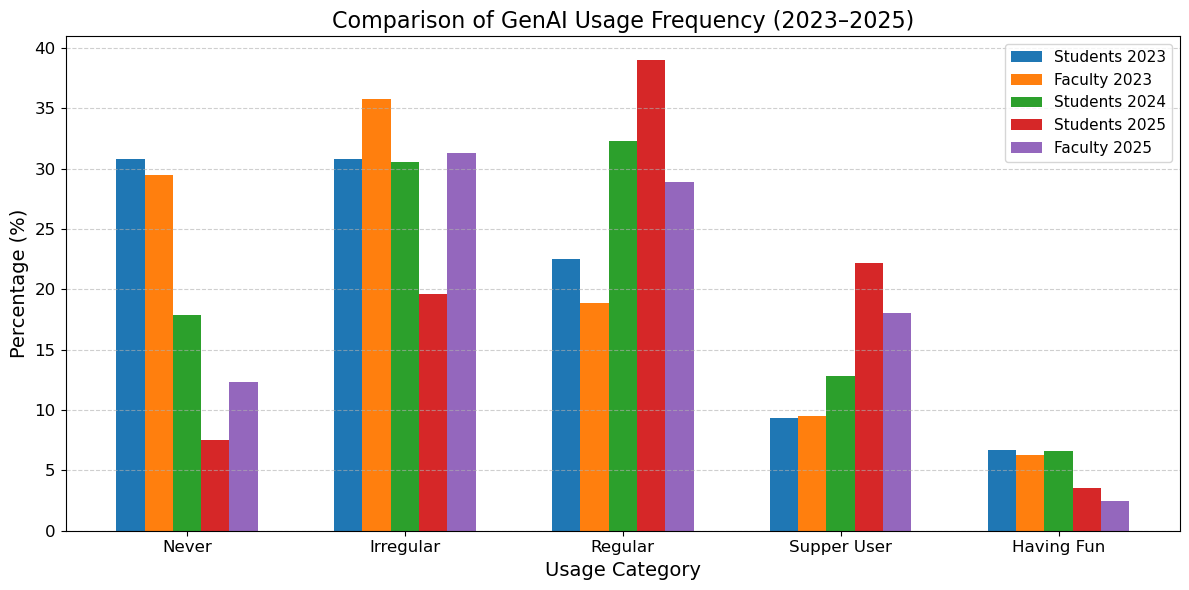

In [29]:
# --- Setup ---
categories = list(student_25.keys())
x = np.arange(len(categories))  # the label locations
width = 0.13  # width of each bar

# --- Extract values ---
student_values_25 = [student_25[c] for c in categories]
faculty_values_25 = [faculty_25[c] for c in categories]
student_values_24 = [student_24[c] for c in categories]
student_values_23 = [student_23[c] for c in categories]
faculty_values_23 = [faculty_23[c] for c in categories]

# --- Plot ---
plt.figure(figsize=(12, 6))

plt.bar(x - 2*width, student_values_23, width, label="Students 2023")
plt.bar(x - width, faculty_values_23, width, label="Faculty 2023")
plt.bar(x, student_values_24, width, label="Students 2024")
plt.bar(x + width, student_values_25, width, label="Students 2025")
plt.bar(x + 2*width, faculty_values_25, width, label="Faculty 2025")

# --- Labels and formatting ---
plt.title("Comparison of GenAI Usage Frequency (2023–2025)", fontsize=16)
plt.xlabel("Usage Category", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.xticks(x, categories, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

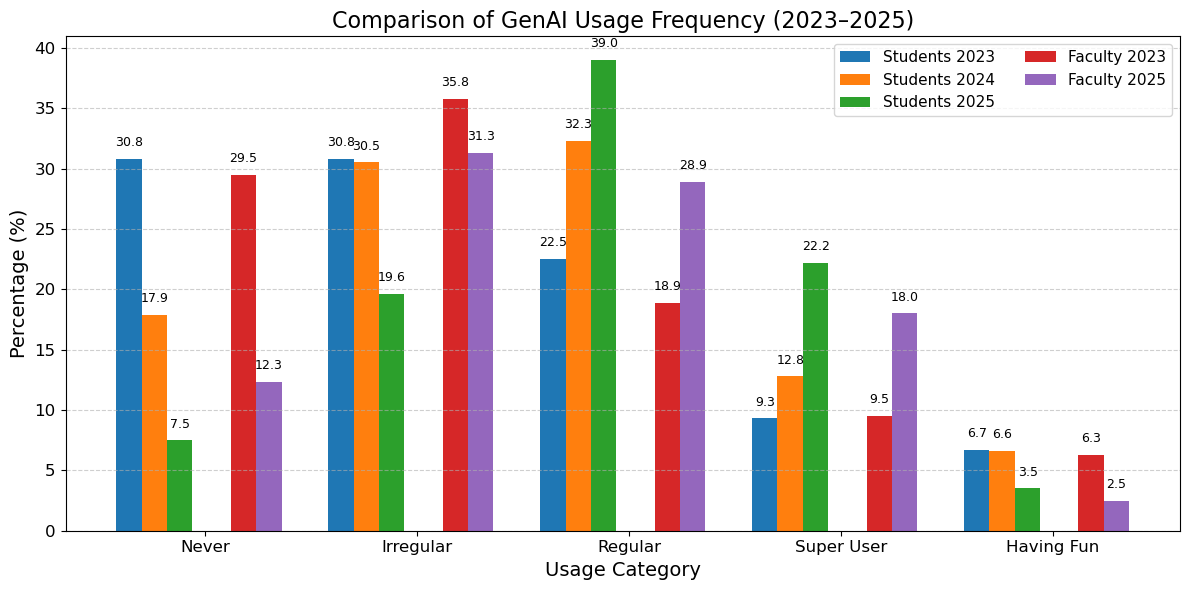

In [41]:
# --- Plot ---
plt.figure(figsize=(12, 6))

# Group 1: Students (3 years)
bars = []
bars.append(plt.bar(x - width, student_values_23, width, label="Students 2023"))
bars.append(plt.bar(x, student_values_24, width, label="Students 2024"))
bars.append(plt.bar(x + width, student_values_25, width, label="Students 2025"))

# Group 2: Faculty (shifted right by 4 widths to separate groups)
faculty_offset = 4 * width
bars.append(plt.bar(x + faculty_offset - width/2, faculty_values_23, width, label="Faculty 2023"))
bars.append(plt.bar(x + faculty_offset + width/2, faculty_values_25, width, label="Faculty 2025"))

# --- Add value labels ---
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.8,
            f"{height:.1f}",
            ha='center', va='bottom', fontsize=9
        )

# --- Labels and formatting ---
plt.title("Comparison of GenAI Usage Frequency (2023–2025)", fontsize=16)
plt.xlabel("Usage Category", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.xticks(x + faculty_offset / 2, categories, fontsize=12)  # center x labels between groups
plt.yticks(fontsize=12)
plt.legend(fontsize=11, ncol=2)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
